<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn9catdog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CNN : 개/고양이 이미지(고해상도) 분류 - 이진분류
!pip install tensorflow_datasets


In [2]:
import os, shutil   # 파일/폴더를 이동, 복사, 삭제할 때 사용 예)  shutil.copy()
import tensorflow_datasets as tfds
print(tfds.list_builders())

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(1)
tf.random.set_seed(1)

['abstract_reasoning', 'accentdb', 'aeslc', 'aflw2k3d', 'ag_news_subset', 'ai2_arc', 'ai2_arc_with_ir', 'ai2dcaption', 'aloha_mobile', 'amazon_us_reviews', 'anli', 'answer_equivalence', 'arc', 'asimov_dilemmas_auto_val', 'asimov_dilemmas_scifi_train', 'asimov_dilemmas_scifi_val', 'asimov_injury_val', 'asimov_multimodal_auto_val', 'asimov_multimodal_manual_val', 'asqa', 'asset', 'assin2', 'asu_table_top_converted_externally_to_rlds', 'austin_buds_dataset_converted_externally_to_rlds', 'austin_sailor_dataset_converted_externally_to_rlds', 'austin_sirius_dataset_converted_externally_to_rlds', 'bair_robot_pushing_small', 'bc_z', 'bccd', 'beans', 'bee_dataset', 'beir', 'berkeley_autolab_ur5', 'berkeley_cable_routing', 'berkeley_fanuc_manipulation', 'berkeley_gnm_cory_hall', 'berkeley_gnm_recon', 'berkeley_gnm_sac_son', 'berkeley_mvp_converted_externally_to_rlds', 'berkeley_rpt_converted_externally_to_rlds', 'big_patent', 'bigearthnet', 'billsum', 'binarized_mnist', 'binary_alpha_digits', 'b

In [ ]:
# data download
(dataset, info) = tfds.load('cats_vs_dogs',with_info=True, as_supervised=True)  # as_supervised : data를 (image, label) 형태로 변환
print(dataset)
print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.SK527M_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
{Split('train'): <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuf

label_names :  ['cat', 'dog']
dict_keys([Split('train')])
(187, 250, 3) <dtype: 'uint8'>
1


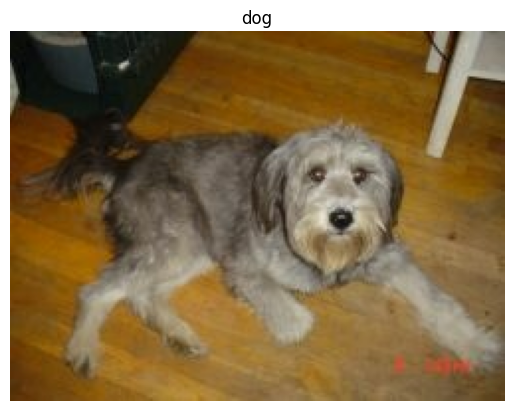

In [ ]:
label_names = info.features['label'].names
print('label_names : ', label_names)   #('cat','dog')
print(dataset.keys())   # train만 지원

for image, label in dataset['train'].skip(250).take(1):
  print(image.shape, image.dtype)
  print(label.numpy())
  plt.imshow(image)
  plt.title(label_names[label.numpy()])
  plt.axis('off')
  plt.show()

In [ ]:
# 폴더 구조 생성
base_dir = './cats_and_dogs_filtered'   # 이미지 루트 폴더
train_dir = os.path.join(base_dir, 'train')   # 학습 폴더
validation_dir = os.path.join(base_dir, 'validation')   # 검증 폴더

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
val_cats_dir = os.path.join(validation_dir, 'cats')
val_dogs_dir = os.path.join(validation_dir, 'dogs')

for d in [train_cats_dir, train_dogs_dir, val_cats_dir, val_dogs_dir]:
  os.makedirs(d, exist_ok=True)

# train/validation 분할 - 이미지 저장
IMG_SIZE = (150, 150)

def save_imageFunc(img, label, idx, split):
  img = tf.image.resize(img, IMG_SIZE)
  img = tf.cast(img, tf.uint8).numpy()  # 텐서를 정수형 이미지로 변환해 numpy 배열로 반환 예) 0.12 -> 0, 255.0 -> 255

  if split == 'train':
    forder = train_cats_dir if label == 0 else train_dogs_dir
  else:
    forder = val_cats_dir if label == 0 else val_dogs_dir

  path = os.path.join(forder, f'{idx}.jpg')
  tf.keras.utils.save_img(path, img)  # 이미지가 해당 경로에 저장


# train data의 일부를 validation으로 사용 (8:2)
total = info.splits['train'].num_examples
print(total)  # 23262

train_size = int(0.8 * total)
print(train_size)   # 18609

for i, (img, label) in enumerate(dataset['train']):
  if i < train_size:
    save_imageFunc(img, label, i, 'train')
  else:
    save_imageFunc(img, label, i, 'validation')

print('데이터 준비 완료  ---')

23262
18609
데이터 준비 완료  ---


In [ ]:
PATH = './cats_and_dogs_filtered'   # 이미지 루트 폴더
train_dir = os.path.join(PATH, 'train')   # 학습 폴더
validation_dir = os.path.join(PATH, 'validation')   # 검증 폴더

train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
val_cats_dir = os.path.join(validation_dir, 'cats')
val_dogs_dir = os.path.join(validation_dir, 'dogs')

for p in [train_dir, train_cats_dir, train_dogs_dir, validation_dir, val_cats_dir, val_dogs_dir]:
  print(p, '->', os.path.exists(p))   # 경로 유무 확인

print('cats(train)', len(os.listdir(train_cats_dir)), '| dogs(train)', len(os.listdir(train_dogs_dir)))
print('cats(val)', len(os.listdir(val_cats_dir)), '| dogs(val)', len(os.listdir(val_dogs_dir)))

./cats_and_dogs_filtered/train -> True
./cats_and_dogs_filtered/train/cats -> True
./cats_and_dogs_filtered/train/dogs -> True
./cats_and_dogs_filtered/validation -> True
./cats_and_dogs_filtered/validation/cats -> True
./cats_and_dogs_filtered/validation/dogs -> True
cats(train) 9381 | dogs(train) 9228
cats(val) 2277 | dogs(val) 2376


In [ ]:
# 참고 : Colab에서 폴더 전체를 내 PC로 다운로드하기
import shutil
from google.colab import files

# 폴더를 zip 파일로 압축
shutil.make_archive(
    './cats_and_dogs_filtered',   # 생성될 zip 파일 이름
    'zip',                        # 압축 형식
    './cats_and_dogs_filtered'    # 압축할 폴더명
    )

files.download('./cats_and_dogs_filtered.zip')  # 내 PC로 다운로드

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 이미지 증강/스케일링
IMG_HEIGHT, IMG_WIDTH = (150, 150)
BATCH_SIZE = 128
EPOCHS = 20  # 실제는 더 큰수 사용

train_datagen = ImageDataGenerator(
    rescale=1./255,  # [0. ,1] 스케일(이미지 픽셀값을 0 ~ 1 사이로 조정)
    rotation_range=15,  # 회전
    width_shift_range=0.1,height_shift_range=0.1, # 평행 이동
    horizontal_flip=True,  # 좌우 반전
)
val_datagen = ImageDataGenerator(rescale=1./255)  # 검증은 스케일만

train_data = train_datagen.flow_from_directory(   # 폴더를 자동 라벨링하여 로드
  train_dir,
  target_size = (IMG_HEIGHT, IMG_WIDTH),
  batch_size = BATCH_SIZE,
  class_mode = 'binary',
  shuffle = True,
)

val_data = val_datagen.flow_from_directory(   # 폴더를 자동 라벨링하여 로드
  validation_dir,
  target_size = (IMG_HEIGHT, IMG_WIDTH),
  batch_size = BATCH_SIZE,
  class_mode = 'binary',
)

print('class_indices:', train_data.class_indices)

Found 18609 images belonging to 2 classes.
Found 4653 images belonging to 2 classes.
class_indices: {'cats': 0, 'dogs': 1}


idx_to_name :  {0: 'cats', 1: 'dogs'}


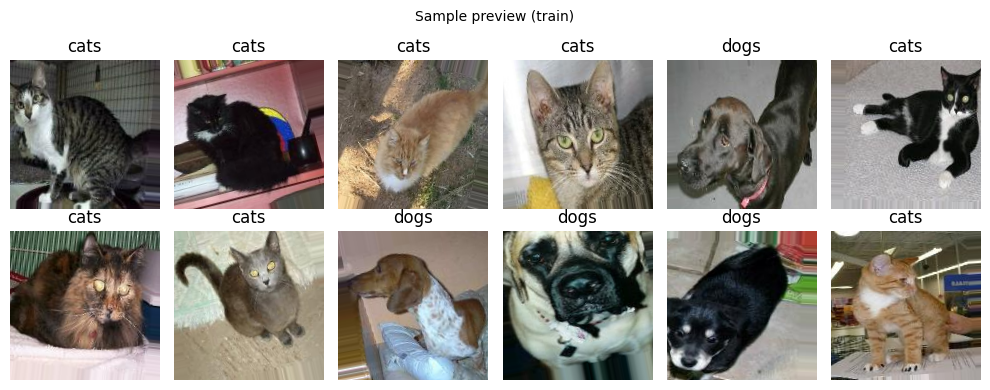

In [ ]:
# 로드된 이미지 미리보기 (한 배치)
imgs, labels = next(train_data)
n_show = min(12, imgs.shape[0]) # 보여줄 샘플 수
cols = 6
rows = int(np.ceil(n_show / cols))

idx_to_name = {v:k for k, v in train_data.class_indices.items() }
print('idx_to_name : ', idx_to_name)  #

plt.figure(figsize=(10, 2*rows))
for i in range(n_show):
  ax = plt.subplot(rows, cols, i+1)
  ax.imshow(imgs[i])
  ax.set_title(f'{idx_to_name[labels[i]]}')
  plt.axis('off')
plt.suptitle('Sample preview (train)', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# model
model = Sequential([
    Input((IMG_HEIGHT, IMG_WIDTH, 3)),
    Conv2D(16, 3, padding='same', activation='relu'),
    MaxPooling2D(),  # feature map의 절반크기로 다운 샘플링 됨

    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D(),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,641,441 (40.59 MB)

 Trainable params: 10,641,441 (40.59 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

os.makedirs('checkpoints', exist_ok=True)
ckpt = ModelCheckpoint(
    filepath= 'chkpoints/catdog_test.keras',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max',
)

es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[ckpt, es], verbose=2
)

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.68472, saving model to chkpoints/catdog_test.keras

Epoch 1: finished saving model to chkpoints/catdog_test.keras
146/146 - 131s - 898ms/step - accuracy: 0.6194 - loss: 0.6884 - val_accuracy: 0.6847 - val_loss: 0.5838
Epoch 2/20

Epoch 2: val_accuracy improved from 0.68472 to 0.73243, saving model to chkpoints/catdog_test.keras

Epoch 2: finished saving model to chkpoints/catdog_test.keras
146/146 - 133s - 913ms/step - accuracy: 0.7046 - loss: 0.5682 - val_accuracy: 0.7324 - val_loss: 0.5266
Epoch 3/20

Epoch 3: val_accuracy improved from 0.73243 to 0.75027, saving model to chkpoints/catdog_test.keras

Epoch 3: finished saving model to chkpoints/catdog_test.keras
146/146 - 118s - 808ms/step - accuracy: 0.7439 - loss: 0.5176 - val_accuracy: 0.7503 - val_loss: 0.5068
Epoch 4/20

Epoch 4: val_accuracy improved from 0.75027 to 0.80443, saving model to chkpoints/catdog_test.keras

Epoch 4: finished saving model to chkpoints/catdog_te

검증 평가 결과 : acc : 0.8769, loss : 0.2883


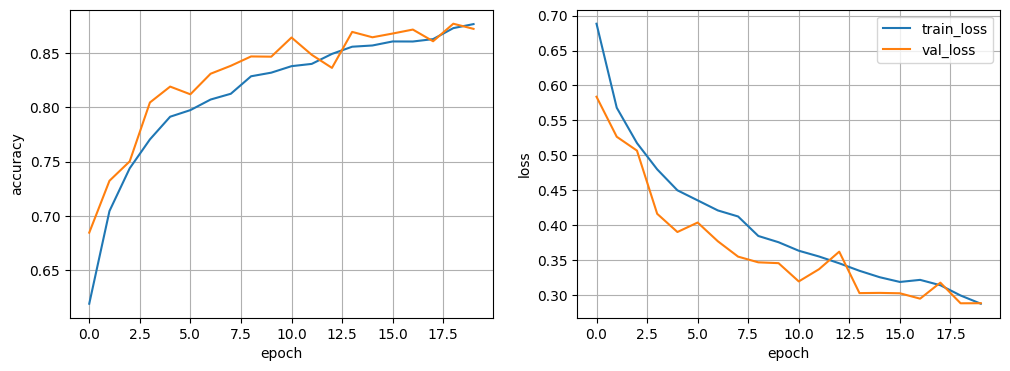

In [ ]:
# 평가 / 시각화
val_loss, val_acc = model.evaluate(val_data, verbose = 0)
print(f'검증 평가 결과 : acc : {val_acc:.4f}, loss : {val_loss:.4f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)

plt.legend()
plt.show()

Found 4653 images belonging to 2 classes.


TypeError: unsupported format string passed to numpy.ndarray.__format__

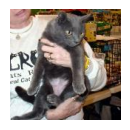

In [ ]:
# 검증 배치 예측 확인
preview_gen = ImageDataGenerator(rescale=1./255)
# 미리보기 전용 : 섞어서 배치 뽑기 (평가용 val_data는 그대로 유지)
preview_flow = preview_gen.flow_from_directory(
      validation_dir,
      target_size = (IMG_HEIGHT, IMG_WIDTH),
      batch_size = 24,
      class_mode = 'binary',
      shuffle = True,
      seed = 123
)

# 예측용 개/고양이 보기(6개)
n_each = 6    # 개/고양이 각각 n개를 모을 때까지 여러 배치 이어받기

cats_images, dogs_images = [], []

while len(cats_images) < n_each or len(dogs_images) < n_each:
  imgs, labels = next(preview_flow)
  for im, lb in zip(imgs, labels.ravel()):
    if lb == 0 and len(cats_images) < n_each:
      cats_images.append(im)
    elif lb == 1 and len(dogs_images) < n_each:
      dogs_images.append(im)

    if len(cats_images) >= n_each and len(dogs_images) >= n_each:
      break

# 예측
cats_probs = model.predict(np.array(cats_images), verbose=0)
dogs_probs = model.predict(np.array(dogs_images), verbose=0)

# 예측 결과 시각화 (0행: 고양이, 1행: 개)
rows, cols = 2, n_each
plt.figure(figsize=(10, 2.5*rows))
for i in range(n_each):
  # cats row
  ax = plt.subplot(rows, cols, i+1)
  ax.imshow(cats_images[i])
  ax.axis('off')
  p = cats_probs[i]
  ax.set_title(f"True cats | Pred:{'dogs' if p >= 0.5 else 'cats'} (p_dog={p:.2f})", fontsize=9)

  # dogs row
  ax = plt.subplot(rows, cols, cols+i+1)
  ax.imshow(dogs_images[i])
  plt.axis('off')
  p = dogs_probs[i]
  ax.set_title(f"True dogs | Pred:{'dogs' if p >= 0.5 else 'cats'} (p_dog={p:.2f})", fontsize=9)

plt.suptitle('validation preveiw (mixed cat&dog)', fontsize=10)
plt.tight_layout()
plt.show()